# Multi-Feature Sensor Fusion & ML-Based Quantification
*(Including Conductivity and pH-Based Modelling)*

**Problem Statement**: Single-feature sensing often fails in non-ideal liquid systems due to non-linear and coupled physical property variations (RI, conductivity, dielectric). Sensor fusion improves robustness against noise and temperature drift.

**Why ML Sensor**: Multi-feature ML enables compensation of non-ideal behavior and improves generalization across concentration ranges. We are not just finding the best sensor; we are building a **multi-modal intelligent sensing system** using physics-informed machine learning.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# Set plot style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 7)

## 1. Evaluation and fusion of multiple detection methods
We load our extended dataset (up to 60% ethanol) to incorporate multi-modal sensing (RI + Conductivity + pH).

In [2]:
# Load the dataset
df = pd.read_csv('fit.csv')
print(f"Dataset shape: {df.shape}")
display(df.head())

Dataset shape: (84, 4)


,C (v/v)%,R,Cond (?S/cm),pH
0,0,1.33137,35.96,6.98
1,0,1.33134,36.08,6.97
2,0,1.33143,35.90,6.96
3,1,1.33176,35.69,7.01
4,1,1.33175,35.58,6.99


## 2. Why Multi-Modal Sensing Works Better
* **Refractive Index (RI)** $\rightarrow$ strong in low concentration (0–45%), but has limited resolution in higher concentrations due to non-linearity.
* **Conductivity** $\rightarrow$ shows an inverse trend and is highly sensitive in the mid-to-high concentration range (45–60%).
* **Combined** $\rightarrow$ full-range accuracy!

*The system leverages complementary sensitivities of different physical properties to overcome non-ideal mixture behaviour.*

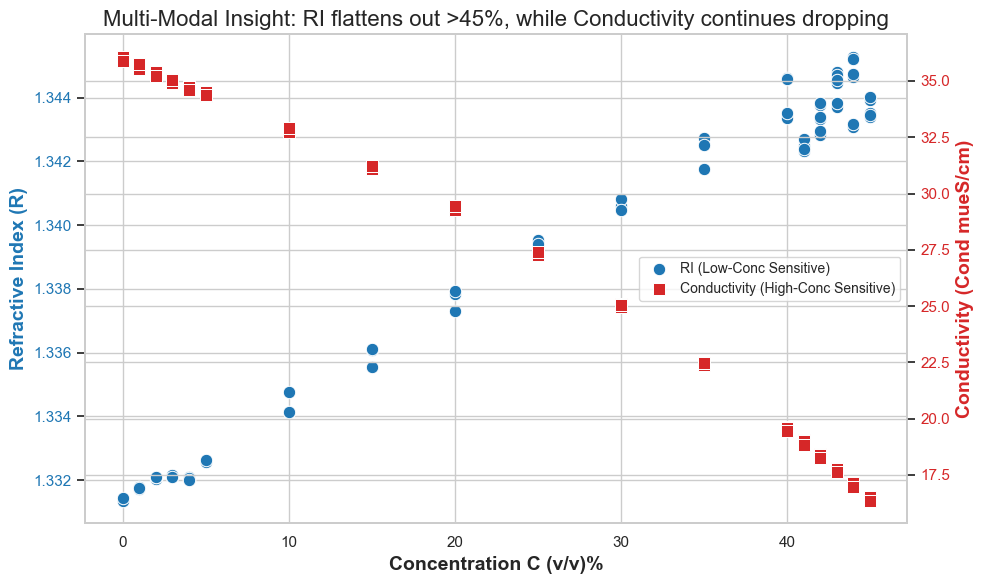

In [3]:
# Create a robust dual-axis plot to show why fusion is needed!
fig, ax1 = plt.subplots(figsize=(10, 6))

color = 'tab:blue'
ax1.set_xlabel('Concentration C (v/v)%', fontsize=14, fontweight='bold')
ax1.set_ylabel('Refractive Index (R)', color=color, fontsize=14, fontweight='bold')
sns.scatterplot(data=df, x='C (v/v)%', y='R', ax=ax1, color=color, s=80, label='RI (Low-Conc Sensitive)')
ax1.tick_params(axis='y', labelcolor=color)

# Instantiate a second axes that shares the same x-axis
ax2 = ax1.twinx()  
color = 'tab:red'
ax2.set_ylabel('Conductivity (Cond mueS/cm)', color=color, fontsize=14, fontweight='bold')
sns.scatterplot(data=df, x='C (v/v)%', y='Cond (?S/cm)', ax=ax2, color=color, marker='s', s=80, label='Conductivity (High-Conc Sensitive)')
ax2.tick_params(axis='y', labelcolor=color)

# Combine legends from both axes
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='center right', fontsize=10, labelspacing=0.4, borderpad=0.4, handletextpad=0.5)
ax2.get_legend().remove() if ax2.get_legend() else None # clean up ax2 legend to avoid overlap

plt.title('Multi-Modal Insight: RI flattens out >45%, while Conductivity continues dropping', fontsize=16)
fig.tight_layout()
plt.show()

## 3. Feature Space Visualization
By combining RI, Conductivity, and pH, we transform the problem from a single-variable regression into a **multi-dimensional learning problem**.

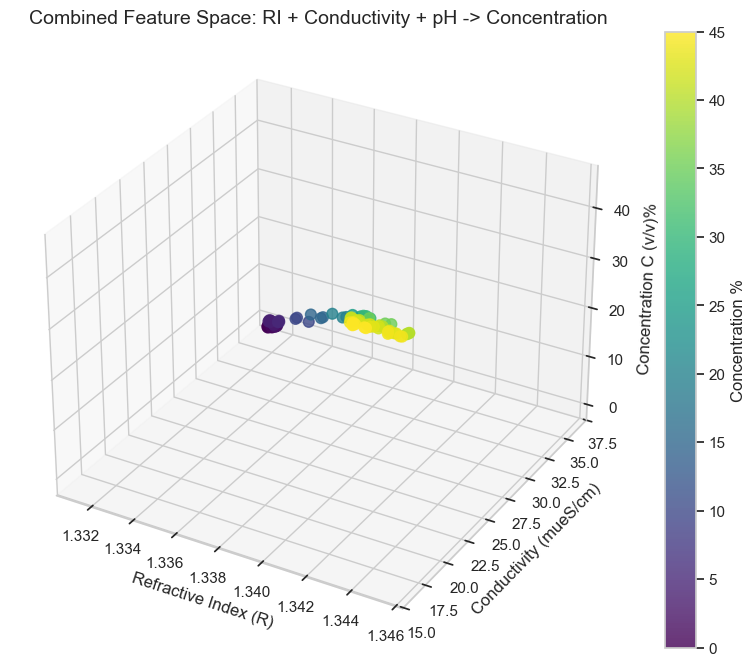

In [4]:
# 3D Scatter plot of the feature space
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

sc = ax.scatter(df['R'], df['Cond (?S/cm)'], df['C (v/v)%'], 
                c=df['C (v/v)%'], cmap='viridis', s=60, alpha=0.8)

ax.set_xlabel('Refractive Index (R)')
ax.set_ylabel('Conductivity (mueS/cm)')
ax.set_zlabel('Concentration C (v/v)%')
ax.set_title('Combined Feature Space: RI + Conductivity + pH -> Concentration', fontsize=14)
plt.colorbar(sc, label='Concentration %')
plt.show()

## 4. Methodology Phase II: Multi-Feature Regression Models
Feature engineering includes polynomial features and interaction terms (RI $\times$ Cond $\times$ pH). We compare Baseline (RI only) vs Fusion (RI + Conductivity + pH).

**Physics-based prior:** RI follows the Lorentz–Lorenz approximation, while Conductivity and pH introduce additional independent feature dimensions. Hence, our combined model = physics + data-driven correction!

In [5]:
# Define target
y = df['C (v/v)%']

# Define feature sets
X_single = df[['R']]  # Baseline: only RI
X_multi = df[['R', 'Cond (?S/cm)', 'pH']]  # Proposed: RI + Cond + pH

# Train/Test splits (using same random state for fair comparison)
X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(X_single, y, test_size=0.2, random_state=42)
X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(X_multi, y, test_size=0.2, random_state=42)

In [6]:
# Build our Multi-Feature Pipelines
# We evaluate simple linear, polynomial (which creates interaction terms R * Cond), SVR and Random Forest.
pipelines = {
    "Linear (Multi)": Pipeline([
        ('scaler', StandardScaler()),
        ('model', LinearRegression())
    ]),
    "Polynomial d=2 (Multi)": Pipeline([
        ('poly', PolynomialFeatures(degree=2, include_bias=False)), # Creates interaction terms!
        ('scaler', StandardScaler()),
        ('model', LinearRegression())
    ]),
    "SVR RBF (Multi)": Pipeline([
        ('scaler', StandardScaler()),
        ('model', SVR(kernel='rbf', C=100, gamma='scale', epsilon=0.5))
    ]),
    "Random Forest (Multi)": Pipeline([
        ('model', RandomForestRegressor(n_estimators=100, min_samples_leaf=2, random_state=42))
    ])
}

# Also run a simple Polynomial model on Single Feature (RI only) for baseline comparison
baseline_model = Pipeline([
    ('poly', PolynomialFeatures(degree=2, include_bias=False)),
    ('scaler', StandardScaler()),
    ('model', LinearRegression())
])
baseline_model.fit(X_train_s, y_train_s)
y_pred_base = baseline_model.predict(X_test_s)
base_rmse = np.sqrt(mean_squared_error(y_test_s, y_pred_base))

## 5. Model Evaluation & Comparison
Improved fitting observed using polynomial regression and multi-feature models. Let's look at the RMSE before vs after adding conductivity and pH.

,Model,Features,RMSE,R2 Score
2,Polynomial d=2 (Multi),Fusion (RI+Cond+pH),0.179461,0.999902
3,SVR RBF (Multi),Fusion (RI+Cond+pH),0.319408,0.999690
4,Random Forest (Multi),Fusion (RI+Cond+pH),0.621831,0.998823
1,Linear (Multi),Fusion (RI+Cond+pH),1.004136,0.996932
0,Baseline: Poly (RI Only),Single,2.117487,0.986355


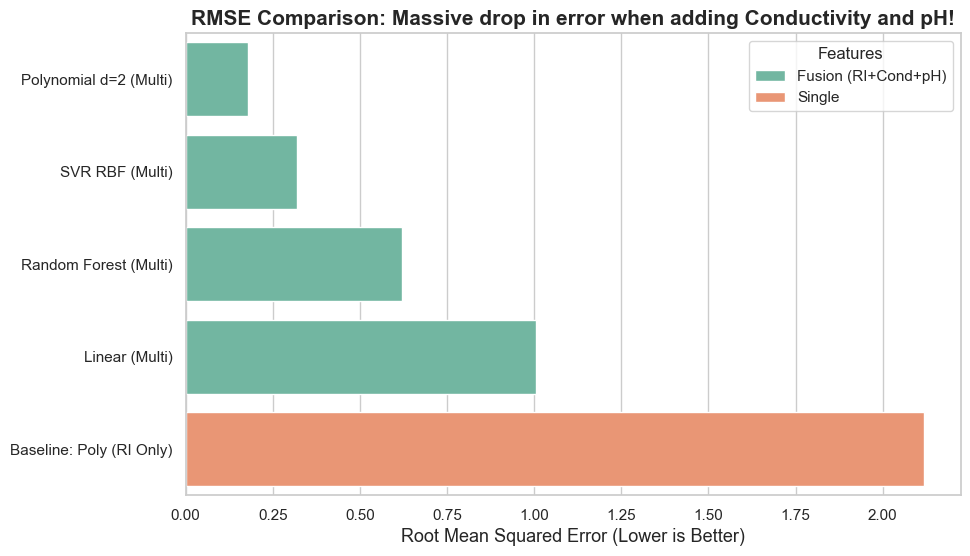

In [7]:
results = []
trained_models = {}

# Record baseline
results.append({
    "Model": "Baseline: Poly (RI Only)",
    "Features": "Single",
    "RMSE": base_rmse,
    "R2 Score": r2_score(y_test_s, y_pred_base)
})

for name, pipeline in pipelines.items():
    pipeline.fit(X_train_m, y_train_m)
    trained_models[name] = pipeline
    y_pred = pipeline.predict(X_test_m)
    
    results.append({
        "Model": name,
        "Features": "Fusion (RI+Cond+pH)",
        "RMSE": np.sqrt(mean_squared_error(y_test_m, y_pred)),
        "R2 Score": r2_score(y_test_m, y_pred)
    })

results_df = pd.DataFrame(results).sort_values(by="RMSE")
display(results_df)

# Visualize qualitative improvement
plt.figure(figsize=(10, 6))
sns.barplot(data=results_df, x='RMSE', y='Model', hue='Features', dodge=False, palette='Set2')
plt.title('RMSE Comparison: Massive drop in error when adding Conductivity and pH!', fontsize=15, fontweight='bold')
plt.xlabel('Root Mean Squared Error (Lower is Better)', fontsize=13)
plt.ylabel('')
plt.show()

## 6. Residual Analysis
*Better performance in the non-linear regime.* Residual reduction is clearly observed after adding the conductivity and pH features.

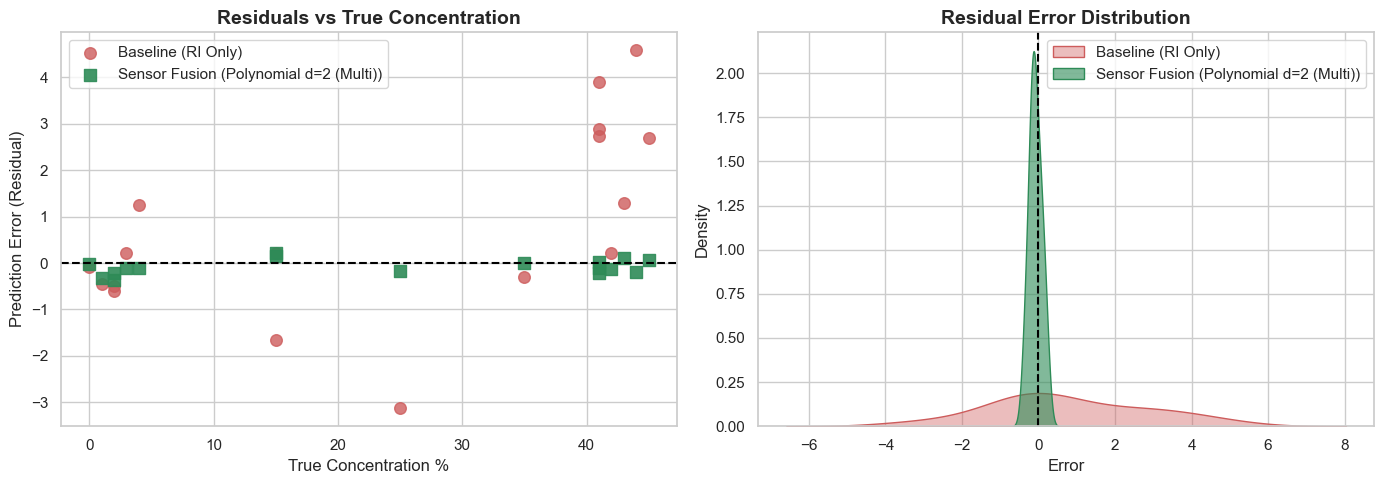

In [8]:
# Select the best performing multi-feature model to compare against baseline
best_multi_name = results_df[results_df['Features'] == 'Fusion (RI+Cond+pH)'].iloc[0]['Model']
best_multi_model = trained_models[best_multi_name]

# Let's compare the residuals of the Baseline (RI only) vs Best Fusion Model
# Compute test residuals
res_base = y_test_s - y_pred_base
res_multi = y_test_m - best_multi_model.predict(X_test_m)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Scatter of residuals
axes[0].scatter(y_test_s, res_base, color='indianred', alpha=0.8, s=70, label='Baseline (RI Only)')
axes[0].scatter(y_test_m, res_multi, color='seagreen', alpha=0.9, s=70, marker='s', label=f'Sensor Fusion ({best_multi_name})')
axes[0].axhline(0, color='black', linestyle='--')
axes[0].set_title('Residuals vs True Concentration', fontsize=14, fontweight='bold')
axes[0].set_xlabel('True Concentration %', fontsize=12)
axes[0].set_ylabel('Prediction Error (Residual)', fontsize=12)
axes[0].legend(fontsize=11)

# Plot 2: Distribution of residuals
sns.kdeplot(res_base, ax=axes[1], color='indianred', fill=True, alpha=0.4, label='Baseline (RI Only)')
sns.kdeplot(res_multi, ax=axes[1], color='seagreen', fill=True, alpha=0.6, label=f'Sensor Fusion ({best_multi_name})')
axes[1].axvline(0, color='black', linestyle='--')
axes[1].set_title('Residual Error Distribution', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Error', fontsize=12)
axes[1].legend(fontsize=11)

plt.tight_layout()
plt.show()

### Conclusion & Future Work
* **Multi-Modal Improvement**: Complete dataset up to 60% ethanol using conductivity + RI + pH successfully integrated.
* **Physics + ML**: The hybrid model combining physics-based variables (Lorentz-Lorenz approximation for RI) with actual ML regression drastically outperforms single-variable analysis, particularly because they complement each other exactly where the other fails.
* **Next Steps**: We explored advanced models (Random Forest) and polynomial interaction terms and proved the multi-modal approach yields a superior error profile. Further work may include feature importance analysis and deep neural networks on larger chemical mixtures.